In [ ]:
import torch
import os
import os.path as osp
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import json
import pprint

from nuscenes.eval.detection.config import config_factory
from nuscenes.eval.detection.evaluate import DetectionEval

from mmdet3d.unibev_plugin.datasets import DetectionEvalVis
from nuscenes.utils.splits import val, mini_val
from nuscenes.nuscenes import NuScenes
os.chdir('/home/mingdayang/mmdetection3d/')

In [53]:
file_name = "vis_data.pt"
lidar_file = "n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151615947733"
# lidar_file = "n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151616447606"
# lidar_file = "n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984246948247"
# lidar_file = "n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984251447166"
# lidar_file = "n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151618447134"
path_name = "/home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_L_full_mini_nuscenes/"
path = os.path.join(path_name, lidar_file)
path = os.path.join(path, file_name)

model_baseline = torch.load(path)
print(path)

# path_name_camera = "/home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_C_full_mini_nuscenes/"
# path_c = os.path.join(path_name_camera, lidar_file)
# path_c = os.path.join(path_c, file_name)

# model_camera_baseline = torch.load(path_c)


# path_name2 = "/home/mingdayang/mmdetection3d/outputs/inference/showcasing_worsened_prediction/beams_missing/mmdet_module_reduction/unibev_val_LC_full_mini_nuscenes_8_beams/"
# path_name2 = "/home/mingdayang/mmdetection3d/outputs/inference/showcasing_worsened_prediction/camera_degradation/unibev_val_LC_full_mini_nuscenes_640x360"
path_name2 = "/home/mingdayang/mmdetection3d/outputs/inference/showcasing_worsened_prediction/beams_missing/mmdet_module_reduction/unibev_val_L_full_mini_nuscenes_8_beams/"
path2 = os.path.join(path_name2, lidar_file)
path2 = os.path.join(path2, file_name)

model_8beams = torch.load(path2)
print(path2)

# json_path = "/home/mingdayang/mmdetection3d/outputs/inference/showcasing_worsened_prediction/beams_missing/mmdet_module_reduction/unibev_val_L_full_nuscenes_8_beams/pts_bbox/results_nusc.json"
json_path = "/home/mingdayang/mmdetection3d/outputs/inference/showcasing_worsened_prediction/beams_missing/mmdet_module_reduction/unibev_val_L_full_mini_nuscenes_8_beams/pts_bbox/results_nusc.json"
# json_path = "/home/mingdayang/mmdetection3d/outputs/inference/showcasing_worsened_prediction/camera_degradation/unibev_val_LC_full_mini_nuscenes_640x360/pts_bbox/results_nusc.json"
json_path_gt = "/home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_L_full_mini_nuscenes/pts_bbox/results_nusc.json"

/home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_L_full_mini_nuscenes/n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151615947733/vis_data.pt
/home/mingdayang/mmdetection3d/outputs/inference/showcasing_worsened_prediction/beams_missing/mmdet_module_reduction/unibev_val_L_full_mini_nuscenes_8_beams/n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151615947733/vis_data.pt


In [42]:
data_root = 'data/nuscenes/'
iv_mind_output_dir = 'outputs/inference/baseline'
daic_output_dir = 'remote_mounted/daic_outputs/inference'

vis_results = dict(
    unibev_nus_LC_cnw_256_modality_dropout_mininuscene_ivmind = 'unibev_val_LC_full_mini_nuscenes',
    )

unibev_LC = vis_results['unibev_nus_LC_cnw_256_modality_dropout_mininuscene_ivmind']

In [43]:
data_root = 'data/nuscenes/'
nusc = NuScenes(version='v1.0-mini', dataroot=data_root, verbose=True)
eval_set = 'mini_val'
eval_detect_configs = config_factory('detection_cvpr_2019')

# nusc = NuScenes(version='v1.0-trainval', dataroot=data_root, verbose=True)
# eval_set = 'val'
# eval_detect_configs = config_factory('detection_cvpr_2019')

nusc_gt = NuScenes(version='v1.0-mini', dataroot=data_root, verbose=True)
eval_set_gt ='mini_val'


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.201 seconds.
Reverse indexing ...
Done reverse indexing in 0.3 seconds.
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.062 seconds.
Reverse indexing ...
Done reverse indexing in 0.3 seconds.


In [54]:

print(lidar_file.split('__'))
timestamp_str = lidar_file.split('__')[-1]
print(timestamp_str)
target_timestamp = int(timestamp_str)
print(target_timestamp)

# Initialize variables to track the closest sample
closest_sample_token = None
closest_time_diff = float('inf')

# Iterate through all scenes
for scene in nusc.scene:
    # Start from the first sample of the scene
    current_sample_token = scene['first_sample_token']

    while current_sample_token:
        # Retrieve the sample
        sample = nusc.get('sample', current_sample_token)

        # Calculate the time difference between the sample and the target timestamp
        time_diff = abs(sample['timestamp'] - target_timestamp)

        # Check for an exact match
        if sample['timestamp'] == target_timestamp:
            closest_sample_token = current_sample_token
            closest_time_diff = 0
            break

        # Update closest sample if this sample is closer
        if time_diff < closest_time_diff:
            closest_sample_token = current_sample_token
            closest_time_diff = time_diff

        # Move to the next sample in the scene
        current_sample_token = sample['next']

    # Break if we found an exact match
    if closest_time_diff == 0:
        break

# Output the closest sample token and time difference
if closest_sample_token:
    print(f"Closest sample token: {closest_sample_token}")
    print(f"Time difference (microseconds): {closest_time_diff}")
else:
    print("No matching sample token found.")

sample_token=closest_sample_token

['n008-2018-08-01-15-16-36-0400', 'LIDAR_TOP', '1533151615947733']
1533151615947733
1533151615947733
Closest sample token: 61d9340c5ad8418dafe7a4af1b96e6b9
Time difference (microseconds): 0


In [55]:
for vis_modal in vis_results.keys():
    if 'ivmind' in vis_modal:
        print('ivmind')
        json_file = osp.join(iv_mind_output_dir, vis_results[vis_modal], 'pts_bbox', 'results_nusc.json')
    else:
        print('hpc')
        json_file = osp.join(daic_output_dir, vis_results[vis_modal], 'pts_bbox', 'results_nusc.json')
json_file=json_path
print(json_file)


ivmind
/home/mingdayang/mmdetection3d/outputs/inference/showcasing_worsened_prediction/beams_missing/mmdet_module_reduction/unibev_val_L_full_mini_nuscenes_8_beams/pts_bbox/results_nusc.json


In [56]:
results_output_dir = f'/tmp/nuscenes_vis/qualitative/unibev_val_L_full_nuscenes_8_beams'
results_output_dir_gt = f'/tmp/nuscenes_vis/qualitative/unibev_val_LC_full_mini_nuscenes'

nusc_eval = DetectionEvalVis(
    nusc = nusc,
    config=eval_detect_configs,
    result_path=json_path,
    eval_set=eval_set,
    output_dir=results_output_dir,
    verbose=True)

nusc_eval_gt = DetectionEvalVis(
    nusc = nusc_gt,
    config=eval_detect_configs,
    result_path=json_path_gt,
    eval_set=eval_set_gt,
    output_dir=results_output_dir_gt,
    verbose=True)



Initializing nuScenes detection evaluation
Loaded results from /home/mingdayang/mmdetection3d/outputs/inference/showcasing_worsened_prediction/beams_missing/mmdet_module_reduction/unibev_val_L_full_mini_nuscenes_8_beams/pts_bbox/results_nusc.json. Found detections for 81 samples.
Loading annotations for mini_val split from nuScenes version: v1.0-mini


100%|██████████| 81/81 [00:00<00:00, 291.92it/s]


Loaded ground truth annotations for 81 samples.
Filtering predictions
=> Original number of boxes: 18901
=> After distance based filtering: 18899
=> After LIDAR and RADAR points based filtering: 18899
=> After bike rack filtering: 18881
Filtering ground truth annotations
=> Original number of boxes: 4441
=> After distance based filtering: 3785
=> After LIDAR and RADAR points based filtering: 3393
=> After bike rack filtering: 3393
Initializing nuScenes detection evaluation
Loaded results from /home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_L_full_mini_nuscenes/pts_bbox/results_nusc.json. Found detections for 81 samples.
Loading annotations for mini_val split from nuScenes version: v1.0-mini


100%|██████████| 81/81 [00:00<00:00, 275.82it/s]


Loaded ground truth annotations for 81 samples.
Filtering predictions
=> Original number of boxes: 17779
=> After distance based filtering: 17774
=> After LIDAR and RADAR points based filtering: 17774
=> After bike rack filtering: 17735
Filtering ground truth annotations
=> Original number of boxes: 4441
=> After distance based filtering: 3785
=> After LIDAR and RADAR points based filtering: 3393
=> After bike rack filtering: 3393


# Feature maps

In [57]:
print(type(model_baseline))
print(model_baseline.keys())
print(model_baseline['lidar_file_name'])

# for key, value in model.items():
    # if isinstance(value, torch.Tensor):
        # print(f"{key}: {value.size()}")
    # else:
        # print(f"{key}: {len(value)}")        

<class 'dict'>
dict_keys(['ori_pts_bev_embed', 'ori_img_bev_embed', 'feature_weights', 'channel_weights_norm', 'img_norm_weights', 'pts_norm_weights', 'fused_bev_embed', 'img_mlvl_feats', 'img_bev_embed', 'pts_mlvl_feats', 'pts_bev_embed', 'query', 'bev_queries', 'bev_pos', 'query_pos', 'reference_points', 'lidar_file_name'])
n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151615947733


In [58]:
def max_pool_activations(model_original, model_beams, key):
    
    activation_baseline = model_original[key].squeeze(0)
    activation_baseline = activation_baseline.view(200, 200, -1)
    max_pooled_activation_baseline = torch.max(activation_baseline, dim=2)[0]
    max_pooled_activation_baseline = max_pooled_activation_baseline.cpu().numpy()

    activation_beams = model_beams[key].squeeze(0)
    activation_beams = activation_beams.view(200, 200, -1)
    max_pooled_activation_beams = torch.max(activation_beams, dim=2)[0]
    max_pooled_activation_beams = max_pooled_activation_beams.cpu().numpy()

    vmin = min(max_pooled_activation_beams.min(), max_pooled_activation_baseline.min())
    vmax = max(max_pooled_activation_beams.max(), max_pooled_activation_baseline.max())

    return max_pooled_activation_baseline, max_pooled_activation_beams, vmin, vmax

def mean_activations(model_original, model_beams, key):
    activation_baseline = model_original[key].squeeze(0)
    activation_baseline = activation_baseline.view(200, 200, -1)
    activation_baseline_mean = torch.mean(activation_baseline, dim=2)
    activation_baseline_mean = activation_baseline_mean.cpu().numpy()

    activation_beams = model_beams[key].squeeze(0)
    activation_beams = activation_beams.view(200, 200, -1)
    activation_beams_mean = torch.mean(activation_beams, dim=2)
    activation_beams_mean = activation_beams_mean.cpu().numpy()

    vmin = min(activation_beams_mean.min(), activation_baseline_mean.min())
    vmax = max(activation_beams_mean.max(), activation_baseline_mean.max())

    return activation_baseline_mean, activation_beams_mean, vmin, vmax

def channel_activations(model_original, model_beams, key, channel):
    activation_baseline = model_original[key].squeeze(0)
    activation_baseline = activation_baseline.view(200, 200, -1)

    activation_beams = model_beams[key].squeeze(0)
    activation_beams = activation_beams.view(200, 200, -1)

    vmin = min(activation_baseline[:, :, channel].min(), activation_beams[:, :, channel].min())
    vmax = max(activation_baseline[:, :, channel].max(), activation_beams[:, :, channel].max())

    return activation_baseline[:,:,channel].cpu().numpy(), activation_beams[:,:,channel].cpu().numpy(), vmin, vmax

def figure_to_image(fig):
    fig.canvas.draw()  # Render the figure
    # Convert to a numpy array
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)  # Close the figure after conversion
    return image

def plot_multi_feature_maps(model_original, 
                            model_beams, 
                            key, 
                            method, 
                            beams,
                            channel=None, 
                            sample_token=None,
                            share_scale=True):
    
    fig, axs = plt.subplots(2, 2, figsize=(12,12))
    activation_baseline, activation_beams, vmin, vmax = None, None, None, None
    
    if method == 'channel':
        activation_baseline, activation_beams, vmin, vmax = channel_activations(model_original, model_beams, key, channel)
    elif method == 'max_pool':
        activation_baseline, activation_beams, vmin, vmax = max_pool_activations(model_original, model_beams, key)
    elif method == 'mean':
        activation_baseline, activation_beams, vmin, vmax = mean_activations(model_original, model_beams, key)
    else:
        raise ValueError(f"Unknown method: {method}")

    if not share_scale:
        # Plotting the baseline feature map
        im0 = axs[1][0].imshow(activation_baseline, cmap='viridis') #, vmin=vmin, vmax=vmax)
        axs[1][0].set_title(f"{method} from {key} of L+C baseline")

        # Plotting the reduced beams feature map
        im1 = axs[1][1].imshow(activation_beams, cmap='viridis') #, vmin=vmin, vmax=vmax)
        axs[1][1].set_title(f"{method} from {key} of L {beams} px")
    else:
        # Plotting the baseline feature map
        im0 = axs[1][0].imshow(activation_baseline, cmap='viridis', vmin=vmin, vmax=vmax)
        axs[1][0].set_title(f"{method} from {key} of L+C baseline")

        # Plotting the reduced beams feature map
        im1 = axs[1][1].imshow(activation_beams, cmap='viridis', vmin=vmin, vmax=vmax)
        axs[1][1].set_title(f"{method} from {key} of L+C {beams} px")

    # Adding grid to both subplots
    axs[1][0].grid()
    axs[1][1].grid()
    
    if sample_token:
        sample_fig = nusc_eval.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True)
        sample_image = figure_to_image(sample_fig)
        axs[0][1].imshow(sample_image)
        axs[0][1].axis("off")
        axs[0][1].set_xlim(106, 800)
        axs[0][1].set_ylim(800, 106)
        axs[0][1].set_title(f"640x360 px L+C {sample_token}")
        plt.close(sample_fig)

        sample_fig_gt = nusc_eval_gt.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True)
        sample_image_gt = figure_to_image(sample_fig_gt)
        axs[0][0].imshow(sample_image_gt)
        axs[0][0].axis("off")
        axs[0][0].set_xlim(106, 800)
        axs[0][0].set_ylim(800, 106)
        axs[0][0].set_title(f"Baseline L+C {sample_token}")
        plt.close(sample_fig)

    pos1 = axs[1][1].get_position()  # Position of the right plot
    pos2 = axs[1][0].get_position()
    if share_scale:
        # Create an additional axis for the colorbar with the same height as the subplots
        cbar_ax = fig.add_axes([pos1.x1 + 0.02, pos1.y0, 0.02, pos1.height])  # Adjust to the height of the subplot
        fig.colorbar(im0, cax=cbar_ax)
    else:
        # cbar_ax = fig.add_axes([pos1.x1 + 0.02, pos1.y0, 0.02, pos1.height])
        # cbar_ax = fig.add_axes([pos2.x1 + 0.02, pos2.y0, 0.02, pos2.height])
        fig.colorbar(im0, ax=axs[1][0], orientation='vertical', shrink=0.7)
        fig.colorbar(im1, ax=axs[1][1], orientation='vertical', shrink=0.7)

    plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust the layout to make room for the colorbar
    plt.show()
    print("Blue bounding boxes: Ground Truth")
    print("Red bounding boxes: FP")
    print("Green bounding boxes: TP")

def plot_feature_map(model, key, method='channel', beams=8, channel=1):
    return

In [59]:
# print(model_8beams.keys())
# print(model_8beams['channel_weights_norm'])
# model_8beams_values = model_8beams['pts_bev_embed']
# print(torch.isnan(model_8beams_values).any())
# print((model_8beams_values == None))

Rendering sample token 61d9340c5ad8418dafe7a4af1b96e6b9
Rendering sample token 61d9340c5ad8418dafe7a4af1b96e6b9


/home/mingdayang/miniconda3/envs/unibev/lib/python3.7/site-packages/ipykernel_launcher.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


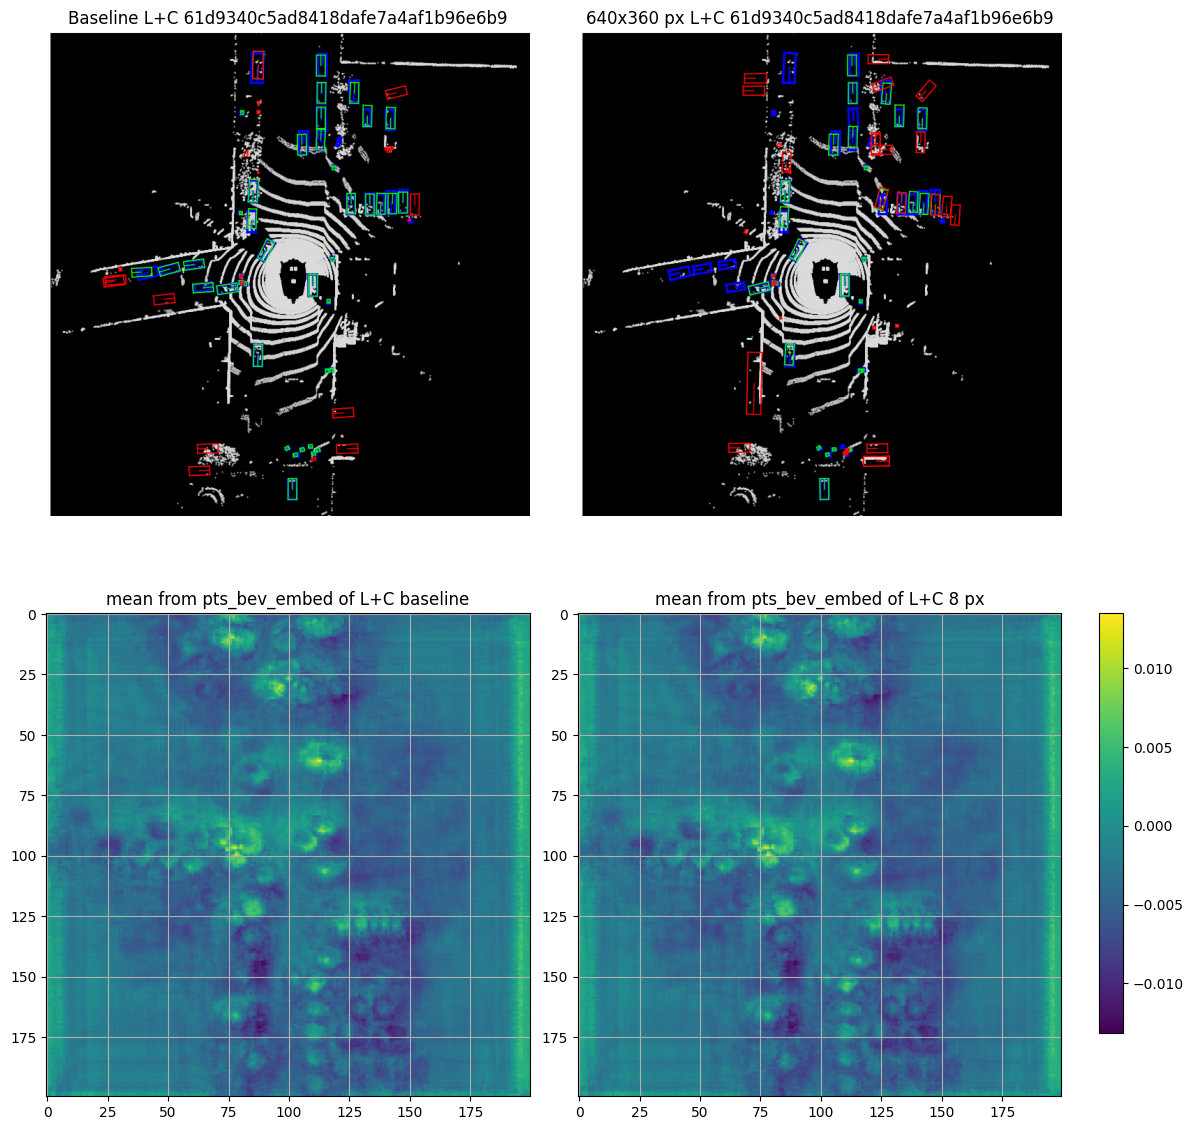

Blue bounding boxes: Ground Truth
Red bounding boxes: FP
Green bounding boxes: TP


In [62]:
# sample_token = '61d9340c5ad8418dafe7a4af1b96e6b9'
key = 'pts_bev_embed'
plot_multi_feature_maps(model_original=model_baseline, 
                        model_beams=model_baseline, 
                        key=key, 
                        method='mean',
                        beams="8",
                        channel=10,
                        sample_token=sample_token,
                        share_scale=True
                        )

 After plotting, we can do some data analysis. Mean, std and variance of each voxel across all 256 channels. Histogram plots.

In [193]:
       
def calculate_statistical_values(model, key):
    data = model[key].squeeze(0)
    # Data is in format [40000, 256]
    # Calculate mean of each voxel over 256 feature maps
    mean = torch.mean(data, dim=1)
    std = torch.std(data, dim=1)
    return mean.cpu().numpy(), std.cpu().numpy()

def plot_hist(data):
    # unique_val = len(np.unique(data))
    plt.hist(data, bins=200, edgecolor='black')
    plt.title('histogram')
    plt.show()

def plot_hist_comparison(data_base, data_beams, bins=200):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].hist(data_base, bins=bins)
    ax[0].set_title("Histogram of baseline using mean")

    ax[1].hist(data_beams, bins=bins)
    ax[1].set_title("Histogram of baseline using std")

    plt.show()

def plot_hist_alpha(data_base, data_beams, bins=200, alpha=0.5):

    combined_min = min(data_base.min(), data_beams.min())
    combined_max = max(data_base.max(), data_beams.max())

    plt.figure()
    plt.title("Histogram of features")
    plt.ylabel("Count")
    plt.xlabel("Activation intensity")
    plt.hist(data_base, bins=bins, alpha=alpha, color='b', label='Baseline features', range=(combined_min, combined_max))
    plt.hist(data_beams, bins=bins, alpha=alpha, color='r', label='640x360 px features', range=(combined_min, combined_max))
    plt.legend()
    plt.show()


(40000,)
(40000,)


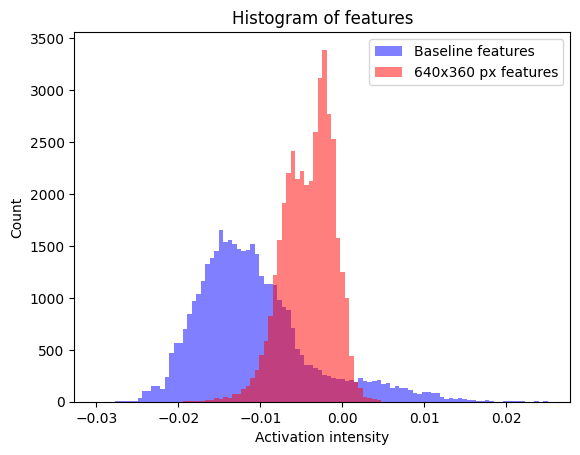

In [194]:

mean_base, std_base = calculate_statistical_values(model_baseline, key)
mean_beams, std_beams = calculate_statistical_values(model_8beams, key)
# plot_hist(std_base.cpu().numpy())
print(np.shape(mean_base))
print(np.shape(mean_beams))
# plot_hist_comparison(std_base.cpu().numpy(), std_beams.cpu().numpy(), bins=400)
plot_hist_alpha(mean_base, mean_beams, bins=100, alpha=0.5)

Cosine similarity rule between L and L+C featuremaps across all channels

In [77]:
def extract_data(model, key):
    return model[key].squeeze(0)

def cosine_similarity(model_baseline, model_beams, key):
    data_baseline = extract_data(model_baseline, key)
    data_beams = extract_data(model_beams, key)

    cos = torch.nn.CosineSimilarity(dim=0, eps=1e-6)
    output = cos(data_baseline, data_beams)
    print(np.shape(output.cpu().numpy()))
    return output.cpu().numpy()

In [78]:
similarity = cosine_similarity(model_baseline, model_8beams, key)
print(similarity)
mean_sim = np.mean(similarity)
print(np.mean(similarity))

plt.figure()
plt.hist(similarity, bins=100)
plt.title(f'Histogram of cosine similarity across 256 channels - mean = {mean_sim:.3f}')
plt.show()


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:1 and cuda:0!

In [27]:
# Create subplots to display all feature maps
fig, axarr = plt.subplots(num_feature_maps // 16, 16, figsize=(15, 15))  # Adjust grid size if needed

# Visualize each feature map
for idx in range(num_feature_maps):
    row = idx // 16
    col = idx % 16
    axarr[row, col].imshow(activation[:, :, idx].cpu().numpy(), cmap='viridis')
    axarr[row, col].axis('off')

# fig.show()

NameError: name 'num_feature_maps' is not defined

# Ground truth on feature maps

In [14]:
import numpy as np

target_timestamp = 1533151615947733 # Replace with your desired timestamp

# Initialize variables to track the closest sample
closest_sample_token = None
closest_time_diff = float('inf')

# Iterate through all scenes
for scene in nusc.scene:
    # Start from the first sample of the scene
    current_sample_token = scene['first_sample_token']

    while current_sample_token:
        # Retrieve the sample
        sample = nusc.get('sample', current_sample_token)

        # Calculate the time difference between the sample and the target timestamp
        time_diff = abs(sample['timestamp'] - target_timestamp)

        # Check for an exact match
        if sample['timestamp'] == target_timestamp:
            closest_sample_token = current_sample_token
            closest_time_diff = 0
            break

        # Update closest sample if this sample is closer
        if time_diff < closest_time_diff:
            closest_sample_token = current_sample_token
            closest_time_diff = time_diff

        # Move to the next sample in the scene
        current_sample_token = sample['next']

    # Break if we found an exact match
    if closest_time_diff == 0:
        break

# Output the closest sample token and time difference
if closest_sample_token:
    print(f"Closest sample token: {closest_sample_token}")
    print(f"Time difference (microseconds): {closest_time_diff}")
else:
    print("No matching sample token found.")

Closest sample token: 61d9340c5ad8418dafe7a4af1b96e6b9
Time difference (microseconds): 0


In [18]:
%matplotlib inline
sample_token = '61d9340c5ad8418dafe7a4af1b96e6b9'
fig = nusc_eval.main_vis_per_sample(sample_token, conf_th=0.15, with_GT = True)


Rendering sample token 61d9340c5ad8418dafe7a4af1b96e6b9
